In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import math
from torch.nn import LayerNorm

In [3]:
from kret_studies import *
from kret_studies.notebook import *
from kret_studies.complex import *

Loaded environment variables from /Users/Akseldkw/Desktop/Columbia/COMS4776/.env.


INFO:datasets:JAX version 0.7.2 available.


In [ ]:
from kret_studies.kret_torch.mixin.constants import DEVICE_TORCH_STR, DEVICE_LITERAL

device: DEVICE_LITERAL = DEVICE_TORCH_STR
NUM_EPOCHS = 1

In [5]:
from trainer import save_model_auto, load_model_auto

In [6]:
# !pip install thop
# !pip install tdqm

# Part 1: Attention and Encoder-Decoder Models

In this section, you'll implement two forms of attention and use them in an encoder-decoder style transformer. You'll then compare performance based on changing dataset size and hidden dimension.

## Step 1: Scaled Dot Product Attention
Implement both the base `scaled_dot_attention` method as well as the `forward` method for the `Attention` module.

In [7]:
def scaled_dot_attention(
    q: torch.Tensor, k: torch.Tensor, v: torch.Tensor, mask: torch.Tensor | None = None
):
    """Computes scaled dot product attention with an optional mask.
      q : shape ( batch, k, hidden_size)
      k : shape ( batch, seq_len, hidden_size)
      v : shape ( batch, seq_len, hidden_size)
      mask: optional. shape (k, seq_len)

    returns:
        context   : shape (batch, k, hidden_size)
        attention : shape (batch, k, seq_len)
    """

    # ------------
    # FILL THIS IN
    # ------------
    unnorm_attn = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(q.size(-1))
    if mask is not None:
        unnorm_attn = unnorm_attn.masked_fill(mask == 0, float("-inf"))
    attention = F.softmax(unnorm_attn, dim=-1)
    context = torch.matmul(attention, v)
    return context, attention

In [8]:
class Attention(nn.Module):
    def __init__(self, hidden_size: int):
        super().__init__()
        self.Q = nn.Linear(hidden_size, hidden_size, bias=False)
        self.K = nn.Linear(hidden_size, hidden_size, bias=False)
        self.V = nn.Linear(hidden_size, hidden_size, bias=False)
        self.hidden_size = hidden_size
        self.to(device)

    def forward(self, x: torch.Tensor, annots: torch.Tensor):
        #   x         : shape ( batch, k, hidden_size)
        #   annots    : shape ( batch, seq_len, hidden_size)

        # ------------
        # FILL THIS IN
        # Pay attention to which inputs you use for the queries, keys, and values.
        # ------------
        # q =
        # k =
        # v =
        q = self.Q(x)
        k = self.K(annots)
        v = self.V(annots)
        return scaled_dot_attention(q, k, v)

## Step 2: Causal Scaled Dot Product Attention
Using your `scaled_dot_attention` method, implement the `forward` method for the `CausalAttention` module.


In [9]:
class CausalAttention(Attention):
    def __init__(self, hidden_size: int):
        super().__init__(hidden_size)
        self.to(device)

    def forward(self, x: torch.Tensor):
        #   x : shape ( batch, seq_len, hidden_size)

        # ------------
        # FILL THIS IN
        # This should be very similar to your other attention implementation,
        # with the exception that you only have one set of outputs and you
        # must construct a causal attention mask.
        # ------------
        # q =
        # k =
        # v =
        # mask =
        seq_len = x.size(1)
        q = self.Q(x)
        k = self.K(x)
        v = self.V(x)
        mask = torch.tril(torch.ones((seq_len, seq_len), device=x.device)).bool()
        return scaled_dot_attention(q, k, v, mask)

#### Simple test cases
##### Passing this DOES NOT mean your implementation is correct. But, if this fails, then you definitely did something wrong

In [10]:
cros_attn = Attention(32)
caus_attn = CausalAttention(32)
caus_attn.Q = cros_attn.Q
caus_attn.K = cros_attn.K
caus_attn.V = cros_attn.V

inp = torch.randn(4, 8, 32).to(device)
inp2 = torch.randn(4, 16, 32).to(device)

print("Checking consistent shape")
assert cros_attn(inp, inp2)[0].shape == inp.shape
assert caus_attn(inp)[0].shape == inp.shape
assert cros_attn(inp, inp2)[1].shape == (4, 8, 16)
assert caus_attn(inp)[1].shape == (4, 8, 8)

print("Checking attention mask")
assert torch.all(caus_attn(inp)[0][:, -1] == cros_attn(inp, inp)[0][:, -1])

print("Passed")

Checking consistent shape
Checking attention mask
Passed


#### Read through the following code. Make sure you understand what is going on.
This code sets up the encoder-decoder architecture. It requires no additional code.

In [11]:
class PositionalEncoding(nn.Module):
    pe: torch.Tensor

    def __init__(self, hidden_size: int, max_len: int = 1000):
        super().__init__()

        pos = torch.arange(max_len).float().unsqueeze(1)
        dim = torch.arange(hidden_size // 2).float().unsqueeze(0)

        div_term = torch.exp(-math.log(10000.0) * (2 * dim) / hidden_size)
        angle = pos * div_term

        pe = torch.zeros(max_len, hidden_size)
        pe[:, 0::2] = torch.sin(angle)
        pe[:, 1::2] = torch.cos(angle)

        self.register_buffer("pe", pe)
        self.to(device)

    def forward(self, idx: int):
        return self.pe[idx]

In [12]:
class MLP(nn.Module):

    def __init__(self, hidden_size: int):
        super().__init__()
        self.layer1 = nn.Linear(hidden_size, hidden_size, bias=False)
        self.layer2 = nn.Linear(hidden_size, hidden_size, bias=False)
        self.relu = nn.ReLU()
        self.to(device)

    def forward(self, x: torch.Tensor):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x


class EncoderBlock(nn.Module):
    def __init__(self, hidden_size: int):
        super().__init__()
        self.norm1 = LayerNorm(hidden_size)
        self.norm2 = LayerNorm(hidden_size)
        self.attn = Attention(hidden_size)
        self.mlp = MLP(hidden_size)
        self.to(device)

    def forward(self, x: torch.Tensor):
        context, attention = self.attn(self.norm1(x), self.norm1(x))
        x = x + context
        x = x + self.mlp(self.norm2(x))
        return x, attention


class DecoderBlock(nn.Module):
    def __init__(self, hidden_size: int):
        super().__init__()
        self.norm1 = LayerNorm(hidden_size)
        self.norm2 = LayerNorm(hidden_size)
        self.cros_attn = Attention(hidden_size)
        self.self_attn = CausalAttention(hidden_size)
        self.mlp = MLP(hidden_size)
        self.to(device)

    def forward(self, x: torch.Tensor, annotation: torch.Tensor):
        context, self_attn = self.self_attn(self.norm1(x))
        x = x + context
        context, cros_attn = self.cros_attn(self.norm2(x), annotation)
        x = x + context
        x = x + self.mlp(self.norm2(x))
        return x, self_attn, cros_attn

In [13]:
class TransformerEncoderDecoder(nn.Module):
    def __init__(self, vocab_size: int, hidden_size: int, num_layers: int):
        super().__init__()

        self.tok_emb = nn.Embedding(vocab_size, hidden_size)
        self.pos_emb = PositionalEncoding(hidden_size)

        self.encoder_blocks = nn.ModuleList(
            [EncoderBlock(hidden_size) for i in range(num_layers)]
        )
        self.decoder_blocks = nn.ModuleList(
            [DecoderBlock(hidden_size) for i in range(num_layers)]
        )

        self.head = nn.Linear(hidden_size, vocab_size, bias=False)
        self.head.weight = self.tok_emb.weight
        # weight tie, the final layer reuses the weights of the embedding layers
        # this reduces the total number of parameters

        self.apply(self._init_weights)  # initialize the weights to a small number
        self.to(device)

    def forward(self, inputs: torch.Tensor, annots: torch.Tensor):

        pos_x = torch.arange(
            0, inputs.shape[-1], device=inputs.device
        ).long()  # creates tensor([0, 1, 2, 3, ...])
        pos_y = torch.arange(
            0, annots.shape[-1], device=inputs.device
        ).long()  # creates tensor([0, 1, 2, 3, ...])

        x = self.tok_emb(inputs) + self.pos_emb(pos_x)
        y = self.tok_emb(annots) + self.pos_emb(pos_y)

        self_attn = []
        cros_attn = []

        for encode in self.encoder_blocks:
            y, _ = encode(y)

        for decode in self.decoder_blocks:
            x, s, c = decode(x, y)
            cros_attn.append(c)
            self_attn.append(s)

        return self.head(x), {"self_attn": self_attn, "cros_attn": cros_attn}

    def _init_weights(self, module: torch.nn.Module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

## Step 3: Training the model

You'll now train a set of example models. This section requires no additional code from you, with the exception of setting the datapath. However, **you are required to analyze and include some of its output**.

In [14]:
from dataset import EncoderDecoderDataset, DecoderDataset
from utils import save_loss_comparison_by_dataset, save_loss_comparison_by_hidden
from torch.utils.data import DataLoader
from trainer import train
import torch.optim as optim


data_path = str("./")  # Change data_path to where the data is stored

encdec_ds_small = EncoderDecoderDataset(data_path, "pig_latin_small")
encdec_ds_large = EncoderDecoderDataset(data_path, "pig_latin_large")

In [15]:
print("Dataset sample:")
print("Input:", encdec_ds_small.to_token(encdec_ds_small[0][0].tolist()))
print("Annotation:", encdec_ds_small.to_token(encdec_ds_small[0][1].tolist()))
print("Target:", encdec_ds_small.to_token(encdec_ds_small[0][2].tolist()))

Dataset sample:
Input: <SOS>endertay
Annotation: tender
Target: endertay<EOS>


In [ ]:
hyper_params = dict(
    vocab_size=len(encdec_ds_small.idx_to_token), hidden_size=16, num_layers=4
)

In [ ]:
# model = load_model_auto(
#     TransformerEncoderDecoder,
#     vocab_size=len(encdec_ds_small.idx_to_token),
#     hidden_size=16,
#     num_layers=4,
# )

[INFO] Loading model weights from /Users/Akseldkw/coding/Columbia/COMS4776-Data/data/homework/HW2/TransformerEncoderDecoder.pt onto mps device.


RuntimeError: Error(s) in loading state_dict for TransformerEncoderDecoder:
	Unexpected key(s) in state_dict: "total_ops", "total_params", "tok_emb.total_ops", "tok_emb.total_params", "pos_emb.total_ops", "pos_emb.total_params", "encoder_blocks.total_ops", "encoder_blocks.total_params", "encoder_blocks.0.total_ops", "encoder_blocks.0.total_params", "encoder_blocks.0.attn.total_ops", "encoder_blocks.0.attn.total_params", "encoder_blocks.0.mlp.total_ops", "encoder_blocks.0.mlp.total_params", "encoder_blocks.1.total_ops", "encoder_blocks.1.total_params", "encoder_blocks.1.attn.total_ops", "encoder_blocks.1.attn.total_params", "encoder_blocks.1.mlp.total_ops", "encoder_blocks.1.mlp.total_params", "encoder_blocks.2.total_ops", "encoder_blocks.2.total_params", "encoder_blocks.2.attn.total_ops", "encoder_blocks.2.attn.total_params", "encoder_blocks.2.mlp.total_ops", "encoder_blocks.2.mlp.total_params", "encoder_blocks.3.total_ops", "encoder_blocks.3.total_params", "encoder_blocks.3.attn.total

In [16]:
model = TransformerEncoderDecoder(
    vocab_size=len(encdec_ds_small.idx_to_token), hidden_size=16, num_layers=4
)

optimizer = optim.AdamW(model.parameters(), lr=1e-2)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

results = train(
    model=model,
    dataset=encdec_ds_small,
    num_epochs=NUM_EPOCHS,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    batch_size=32,
)
save_model_auto(model)

Epoch 1 | Train loss: 2.612364 | Val loss 2.317475
Epoch 2 | Train loss: 2.143391 | Val loss 1.934303
Epoch 3 | Train loss: 1.819578 | Val loss 1.631461
Epoch 4 | Train loss: 1.487871 | Val loss 1.261858
Epoch 5 | Train loss: 1.051621 | Val loss 0.832828


PosixPath('/Users/Akseldkw/coding/Columbia/COMS4776-Data/data/homework/HW2/TransformerEncoderDecoder.pt')

In [17]:
def encdec_generate(
    input: str,
    model: TransformerEncoderDecoder,
    dataset: EncoderDecoderDataset,
    max_len: int = 20,
):
    gen_string = ""
    idx = torch.tensor([[dataset.start_idx]]).to(device)
    annots = torch.tensor(
        [dataset.to_idx(input) + [dataset.end_idx] * (max(0, 12 - len(input)))]
    ).to(device)
    # pad the input string with <EOS> since the collate_fn had to pad the stirngs

    for i in range(max_len):
        logits = model(idx, annots)[0]

        token_idx: torch.Tensor = logits[0, -1:].argmax(dim=-1)
        idx = torch.cat([idx, token_idx.unsqueeze(0)], dim=1)

        if token_idx.item() == dataset.end_idx:
            break
        else:
            gen_string = gen_string + dataset.idx_to_token[int(token_idx.item())]
    return gen_string


def encdec_translate(
    sentence: str, model: TransformerEncoderDecoder, dataset: EncoderDecoderDataset
):
    words = sentence.split()
    return " ".join([encdec_generate(w, model, dataset) for w in words])

In [18]:
encdec_translate("the", model, encdec_ds_small)

'eeay'

In [19]:
encdec_translate("the air conditioning is working", model, encdec_ds_small)

'eeay airay onditinnggggggway ishay orkingway'

In [20]:
encdec_translate("testing some random words", model, encdec_ds_small)

'estingay omeway andomhay ordsay'

In [21]:
configs = [
    (16, "small", encdec_ds_small),
    (16, "large", encdec_ds_large),
    (32, "small", encdec_ds_small),
    (32, "large", encdec_ds_large),
]

all_results = {}

for hidden_size, dataset_name, dataset in configs:
    print(f"\nTraining model: hidden_size={hidden_size}, dataset={dataset_name}")

    model = TransformerEncoderDecoder(
        vocab_size=len(dataset.idx_to_token), hidden_size=hidden_size, num_layers=4
    )
    optimizer = optim.AdamW(model.parameters(), lr=1e-2)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

    results = train(
        model=model,
        dataset=dataset,
        num_epochs=NUM_EPOCHS,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        batch_size=32 if dataset_name == "small" else 256,
    )
    all_results[(hidden_size, dataset_name)] = results
    save_model_auto(model, model_specs=f"_hidden{hidden_size}_dataset{dataset_name}_")

save_loss_comparison_by_dataset(all_results)
save_loss_comparison_by_hidden(all_results)


Training model: hidden_size=16, dataset=small
Epoch 1 | Train loss: 2.609225 | Val loss 2.311422
Epoch 2 | Train loss: 2.136539 | Val loss 1.983080
Epoch 3 | Train loss: 1.859636 | Val loss 1.687606
Epoch 4 | Train loss: 1.602000 | Val loss 1.533576
Epoch 5 | Train loss: 1.287413 | Val loss 1.072361

Training model: hidden_size=16, dataset=large
Epoch 1 | Train loss: 2.603790 | Val loss 2.285194
Epoch 2 | Train loss: 2.095810 | Val loss 1.927817
Epoch 3 | Train loss: 1.731909 | Val loss 1.523401
Epoch 4 | Train loss: 1.304769 | Val loss 0.979905
Epoch 5 | Train loss: 0.808880 | Val loss 0.595949

Training model: hidden_size=32, dataset=small
Epoch 1 | Train loss: 2.549985 | Val loss 2.234112
Epoch 2 | Train loss: 2.068233 | Val loss 1.936863
Epoch 3 | Train loss: 1.735857 | Val loss 1.445345
Epoch 4 | Train loss: 1.173410 | Val loss 0.868615
Epoch 5 | Train loss: 0.607952 | Val loss 0.489162

Training model: hidden_size=32, dataset=large
Epoch 1 | Train loss: 2.531331 | Val loss 2.364

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

# Part 2: Decoder-only Transformers and Multi-Head Attention

In this section, you'll train transformers that only use a decoder instead of a dual encoder-decoder architecture. You'll also implement and experiment with multi-head attention. Finally, you'll compare increasing parameter count with multi-head attention vs. increasing the parameter count with a larger hidden dimensionality.

## Step 1: Implement the Decoder-Only Forward Method

In [22]:
class DecoderOnlyBlock(nn.Module):
    def __init__(self, hidden_size: int):
        super().__init__()
        self.norm1 = LayerNorm(hidden_size)
        self.norm2 = LayerNorm(hidden_size)
        self.attn = CausalAttention(hidden_size)
        self.mlp = MLP(hidden_size)

    def forward(self, x: torch.Tensor):
        context, attention = self.attn(self.norm1(x))
        x = x + context
        x = x + self.mlp(self.norm2(x))
        return x, attention


class DecoderTransformer(nn.Module):
    def __init__(self, vocab_size: int, hidden_size: int, num_layers: int):
        super().__init__()

        self.tok_emb = nn.Embedding(vocab_size, hidden_size)
        self.pos_emb = PositionalEncoding(hidden_size)

        self.blocks = nn.ModuleList(
            [DecoderOnlyBlock(hidden_size) for i in range(num_layers)]
        )
        self.head = nn.Linear(hidden_size, vocab_size, bias=False)
        self.head.weight = self.tok_emb.weight
        # weight tie, the final layer reuses the weights of the embedding layers
        # this reduces the total number of parameters

    def forward(self, inputs: torch.Tensor):
        """Forward pass of the Transformer decoder.

        Arguments:
            inputs: Input token indexes across a batch for all the time step. (batch_size x decoder_seq_len)
        Returns:
            output: Un-normalized scores for each token in the vocabulary, across a batch for all the decoding time steps. (batch_size x decoder_seq_len x vocab_size)
            attentions: The stacked attention weights applied to the encoder annotations (batch_size x encoder_seq_len x decoder_seq_len)
        """
        # ------------
        # FILL THIS IN
        # ------------
        # pos =
        # x =
        # self_attn = []

        # for block in self.blocks:
        #     ...
        #
        # unormalized_scores =
        pos = torch.arange(0, inputs.shape[-1], device=inputs.device).long()
        x = self.tok_emb(inputs) + self.pos_emb(pos)
        self_attn = []
        for block in self.blocks:
            x, s = block(x)
            self_attn.append(s)
        unormalized_scores = self.head(x)

        return unormalized_scores, {"self_attn": self_attn}

In [23]:
decoder_ds_small = DecoderDataset(data_path, "pig_latin_small")
decoder_ds_large = DecoderDataset(data_path, "pig_latin_large")

In [24]:
print("Dataset sample:")
print("Input:", decoder_ds_small.to_token(decoder_ds_small[0][0].tolist()))
print("Target:", decoder_ds_small.to_token(decoder_ds_small[0][1].tolist()))

Dataset sample:
Input: <SOS>tender<EOP>endertay
Target: tender<EOP>endertay<EOS>


## Step 2: Format for decoder-only generation.

Implement the missing line in `decoder_generate` to create an input string that looks like:

```
<SOS> input sequence <EOP>
```
You should use the `dataset.start_idx`, `dataset.eop_idx` attributes and the `dataset.to_idx()` method.

In [25]:
def decoder_generate(
    input: str,
    model: DecoderTransformer,
    dataset: DecoderDataset,
    max_len: int = 20,
):
    gen_string = ""
    # idx = TODO
    idx = dataset.to_idx(input)
    idx = torch.tensor([idx]).to(device)

    for i in range(max_len):
        logits = model(idx)[0]

        token_idx = logits[0, -1:].argmax(dim=-1)
        idx = torch.cat([idx, token_idx.unsqueeze(0)], dim=1)

        if token_idx.item() == dataset.end_idx:
            break
        else:
            gen_string = gen_string + dataset.idx_to_token[token_idx.item()]
    return gen_string


def decoder_translate(
    sentence: str, model: DecoderTransformer, dataset: DecoderDataset
):
    words = sentence.split()
    return " ".join([decoder_generate(w, model, dataset) for w in words])

## Step 3: Train the model

We'll now train a decoder only model and test it out on an example. Use the output of this to guide your answer for question 3.

In [26]:
model = DecoderTransformer(
    vocab_size=len(decoder_ds_small.idx_to_token), hidden_size=16, num_layers=4
)

optimizer = optim.AdamW(model.parameters(), lr=1e-2)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

results = train(
    model=model,
    dataset=decoder_ds_small,
    num_epochs=NUM_EPOCHS,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    batch_size=32,
)
save_model_auto(model)

Epoch 1 | Train loss: 3.039172 | Val loss 1.871830
Epoch 2 | Train loss: 1.740094 | Val loss 1.620957
Epoch 3 | Train loss: 1.518615 | Val loss 1.417852
Epoch 4 | Train loss: 1.292315 | Val loss 1.144525
Epoch 5 | Train loss: 1.051456 | Val loss 0.968881


PosixPath('/Users/Akseldkw/coding/Columbia/COMS4776-Data/data/homework/HW2/DecoderTransformer.pt')

In [27]:
decoder_translate("the air conditioning is working", model, decoder_ds_small)

'tttttttttttttttttttt lllllowlowlorlorlorl oloororconcioliovcoo isisisisissssisisssi wwwwwwwwwwwwwwwwwwww'

## Step 4: Implement Multi-Head Attention

In this next step, you'll implement multi-head attention. In this setting, we'll have the dimensionality for each of the heads be (total hidden dimensionality)/(number of heads). We'll use a projection head to combine the outputs of these different attention heads after concatenating their outputs together (which can also be achieved using tensor reshaping).

In [28]:
# TO DO:


def multihead_scaled_dot_attention(
    q: torch.Tensor, k: torch.Tensor, v: torch.Tensor, mask: torch.Tensor | None = None
):
    """Compute multi-head dot product attention.
      q : shape (batch, num_heads, k, hidden_size)
      k : shape (batch, num_heads, seq_len, hidden_size)
      v : shape (batch, num_heads, seq_len, hidden_size)

    returns:
        context   : shape (batch, num_heads, k, hidden_size)
        attention : shape (batch, num_heads, k, seq_len)
    """
    # Hint: if you implemented scaled_dot_attention well, the code for this should be the exact same.

    # ------------
    # FILL THIS IN
    # ------------
    # unnorm_attn =
    # masked_unnorm_attn =
    # attention =
    # context =
    unnorm_attn = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(q.size(-1))
    if mask is not None:
        unnorm_attn = unnorm_attn.masked_fill(mask == 0, float("-inf"))
    attention = F.softmax(unnorm_attn, dim=-1)
    context = torch.matmul(attention, v)
    return context, attention

In [29]:
class MultiheadCausalAttention(Attention):
    proj: nn.Linear

    def __init__(self, hidden_size: int, num_heads: int):
        super().__init__(hidden_size)
        # self.Q, self.K, self.V already defined as nn.Linear(hidden_size, hidden_size)
        self.num_heads = num_heads
        # ------------
        # FILL THIS IN
        # ------------
        # if self.num_heads > 1:
        #   self.proj = nn.Linear( ,  , bias=False)
        if self.num_heads > 1:
            self.proj = nn.Linear(hidden_size, hidden_size, bias=False)
        self.to(device)

    def forward(self, x: torch.Tensor):
        """Compute causal multi-head dot product attention from an input sequence.
          x : shape ( batch, seq_len, hidden_size)
          k : shape (batch, num_heads, seq_len, hidden_size)
          v : shape (batch, num_heads, seq_len, hidden_size)

        returns:
            context : shape ( batch, seq_len, hidden_size)
            attention : shape (batch, num_heads, k, seq_len)
        """
        # ------------
        # FILL THIS IN
        # ------------
        # unnorm_attn =
        # masked_unnorm_attn =
        # attention =
        # context =

        # B, T, C = x.size()
        # q = self.Q(x).view( ,  ,  ,  ).transpose(1, 2)
        # k = self.K(x).view( ,  ,  ,  ).transpose(1, 2)
        # v = self.V(x).view( ,  ,  ,  ).transpose(1, 2)

        # mask =

        # context, attention = multihead_scaled_dot_attention(q, k, v, mask)

        # Hint: you may find the .transpose(), .contiguous(), and .view()
        # methods helpful for creating the reshaped context.

        # reshaped_context =

        # Only perform a projection if the number of heads is more than 1.
        B, T, C = x.size()
        q = self.Q(x).view(B, T, self.num_heads, C // self.num_heads).transpose(1, 2)
        k = self.K(x).view(B, T, self.num_heads, C // self.num_heads).transpose(1, 2)
        v = self.V(x).view(B, T, self.num_heads, C // self.num_heads).transpose(1, 2)
        mask = torch.tril(torch.ones((T, T), device=x.device)).bool()
        context, attention = multihead_scaled_dot_attention(q, k, v, mask)
        reshaped_context = context.transpose(1, 2).contiguous().view(B, T, C)
        if self.num_heads > 1:

            return self.proj(reshaped_context), attention

        else:

            return reshaped_context, attention

In [30]:
class MultiheadDecoderBlock(DecoderOnlyBlock):
    def __init__(self, hidden_size: int, num_heads: int):
        super().__init__(hidden_size)
        self.attn = MultiheadCausalAttention(hidden_size, num_heads)
        self.to(device)


class MultiheadDecoderTransformer(DecoderTransformer):
    def __init__(
        self, vocab_size: int, hidden_size: int, num_layers: int, num_heads: int
    ):
        super().__init__(vocab_size, hidden_size, num_layers)
        self.num_heads = num_heads
        self.num_layers = num_layers
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size

        self.blocks = nn.ModuleList(
            [MultiheadDecoderBlock(hidden_size, num_heads) for i in range(num_layers)]
        )
        self.to(device)

## Step 5: Compare Parameter Usage Methods

Here, you'll train 5 models with varying numbers of attention heads and hidden dimensionalities. You'll compare their parameter efficiency. Start by implementing the `calc_parameters_decoder` method, and then run the code to train the models.

In [31]:
def calc_parameters_decoder(model: MultiheadDecoderTransformer) -> int:
    # ------------
    # FILL THIS IN
    # ------------
    # params = TODO # embedding
    # params +=  TODO # QKV linear projections
    # if model.num_heads > 1:
    #   params += TODO # attention linear projection
    # params += TODO # MLP linear
    # params += TODO # layer norms Hint: LayerNorm(x) uses x parameters

    # Hint: Read the code carefully:
    # params += TODO # head
    params = model.vocab_size * model.hidden_size  # embedding
    params += 3 * (model.hidden_size * model.hidden_size)  # QKV linear projections
    if model.num_heads > 1:
        params += model.hidden_size * model.hidden_size  # attention linear projection
    params += 2 * (
        4 * model.hidden_size * model.hidden_size
    )  # MLP linear (2 per block)
    params += 2 * 2 * model.hidden_size  # layer norms (2 per block)

    return params


Training model: hidden_size=16, num_heads=4, num_layers=4
Epoch 1 | Train loss: 2.098862 | Val loss 1.267634
Epoch 2 | Train loss: 1.056964 | Val loss 0.856451
Epoch 3 | Train loss: 0.692937 | Val loss 0.552133
Epoch 4 | Train loss: 0.452895 | Val loss 0.354556
Epoch 5 | Train loss: 0.293008 | Val loss 0.231678

Training model: hidden_size=16, num_heads=2, num_layers=4
Epoch 1 | Train loss: 2.183045 | Val loss 1.394631
Epoch 2 | Train loss: 1.147436 | Val loss 0.828857
Epoch 3 | Train loss: 0.643433 | Val loss 0.525713
Epoch 4 | Train loss: 0.386331 | Val loss 0.303868
Epoch 5 | Train loss: 0.269888 | Val loss 0.177589

Training model: hidden_size=16, num_heads=1, num_layers=4
Epoch 1 | Train loss: 2.199759 | Val loss 1.491050
Epoch 2 | Train loss: 1.291142 | Val loss 1.153070
Epoch 3 | Train loss: 1.001309 | Val loss 0.903253
Epoch 4 | Train loss: 0.716921 | Val loss 0.578290
Epoch 5 | Train loss: 0.448826 | Val loss 0.306478

Training model: hidden_size=24, num_heads=1, num_layers=4

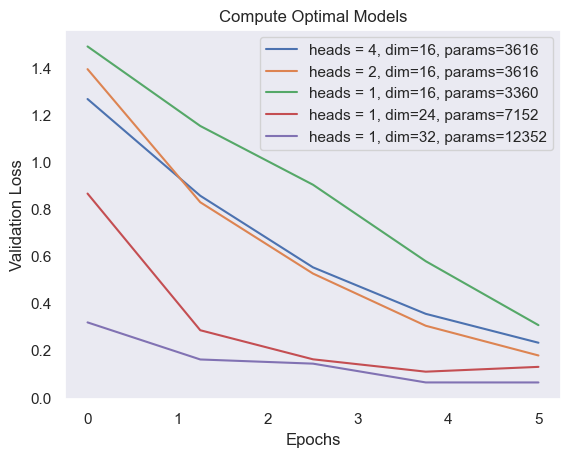

In [32]:
import matplotlib.pyplot as plt
import numpy as np

configs = [
    (16, 4, 4, 64),  # (hidden_size, num_heads, num_layers, batch_size)
    (16, 2, 4, 64),
    (16, 1, 4, 64),
    (24, 1, 4, 64),
    (32, 1, 4, 64),
]

all_results = {}

for hidden_size, num_heads, num_layers, batch_size in configs:
    print(
        f"\nTraining model: hidden_size={hidden_size}, num_heads={num_heads}, num_layers={num_layers}"
    )

    model = MultiheadDecoderTransformer(
        vocab_size=len(decoder_ds_large.idx_to_token),
        hidden_size=hidden_size,
        num_layers=num_layers,
        num_heads=num_heads,
    )

    optimizer = optim.AdamW(model.parameters(), lr=5e-3)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

    results = train(
        model=model,
        dataset=decoder_ds_large,
        num_epochs=NUM_EPOCHS,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        batch_size=batch_size,
    )
    save_model_auto(
        model,
        model_specs=f"_heads{num_heads}_dim{hidden_size}_layers{num_layers}_batch{batch_size}_",
    )

    parameters = calc_parameters_decoder(model)
    x_points = np.linspace(0, len(results["val_loss"]), len(results["val_loss"]))
    plt.plot(
        x_points,
        results["val_loss"],
        label="heads = {}, dim={}, params={}".format(
            num_heads, hidden_size, parameters
        ),
    )

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Compute Optimal Models")
plt.grid()
plt.legend()
plt.show()

In [33]:
plt.clf()

<Figure size 640x480 with 0 Axes>

# Part 3: IsoFLOP Profiling and Scaling Laws
In this final section, you'll compare different architectures based on their compute efficiency. You will also determine the optimal number of parameters and tokens for a fixed compute budget.

While this section does not require any additional code from you, **use the output of it to guide your written responses**.

In [34]:
from utils import (
    plot_scaling_law,
    plot_scaling_law_poly,
    interpolate,
    plot_flops_tokens,
    plot_isoflop,
    plot_flops_params,
)

import numpy as np

## Step 1: Train models, Compare FLOPS vs Validation Loss

We'll inspect the compute efficiency of different models by plotting their validation loss against the number of FLOPs used in training up to that point.

In [35]:
from types_hw2 import TrainerHistDict

In [36]:
configs = [
    (40, 2, 4, 256),  # (hidden_size, num_heads, num_layers, batch_size)
    (32, 2, 4, 128),
    (24, 2, 4, 64),
    (16, 1, 4, 64),
    (16, 1, 3, 64),
    (12, 1, 3, 64),
    (12, 1, 2, 64),
]

all_results: dict[int, TrainerHistDict] = {}

for hidden_size, num_heads, num_layers, batch_size in configs:
    print(
        f"\nTraining model: hidden_size={hidden_size}, num_heads={num_heads}, num_layers={num_layers}"
    )

    model = MultiheadDecoderTransformer(
        vocab_size=len(decoder_ds_large.idx_to_token),
        hidden_size=hidden_size,
        num_layers=num_layers,
        num_heads=num_heads,
    )

    optimizer = optim.AdamW(model.parameters(), lr=5e-3)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

    results = train(
        model=model,
        dataset=decoder_ds_large,
        num_epochs=NUM_EPOCHS,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        batch_size=batch_size,
    )
    save_model_auto(
        model,
        model_specs=f"_heads{num_heads}_dim{hidden_size}_layers{num_layers}_batch{batch_size}_",
    )

    parameters = calc_parameters_decoder(model)
    all_results[parameters] = results


Training model: hidden_size=40, num_heads=2, num_layers=4
Epoch 1 | Train loss: 4.217704 | Val loss 1.340836
Epoch 2 | Train loss: 0.778090 | Val loss 0.333496
Epoch 3 | Train loss: 0.222306 | Val loss 0.129163
Epoch 4 | Train loss: 0.100856 | Val loss 0.091269
Epoch 5 | Train loss: 0.060669 | Val loss 0.065951

Training model: hidden_size=32, num_heads=2, num_layers=4
Epoch 1 | Train loss: 2.709314 | Val loss 0.861195
Epoch 2 | Train loss: 0.437556 | Val loss 0.188226
Epoch 3 | Train loss: 0.146185 | Val loss 0.096808
Epoch 4 | Train loss: 0.085893 | Val loss 0.051267
Epoch 5 | Train loss: 0.057183 | Val loss 0.054508

Training model: hidden_size=24, num_heads=2, num_layers=4
Epoch 1 | Train loss: 1.800489 | Val loss 0.592983
Epoch 2 | Train loss: 0.362296 | Val loss 0.163115
Epoch 3 | Train loss: 0.154386 | Val loss 0.110780
Epoch 4 | Train loss: 0.098585 | Val loss 0.071964
Epoch 5 | Train loss: 0.075654 | Val loss 0.060331

Training model: hidden_size=16, num_heads=1, num_layers=4

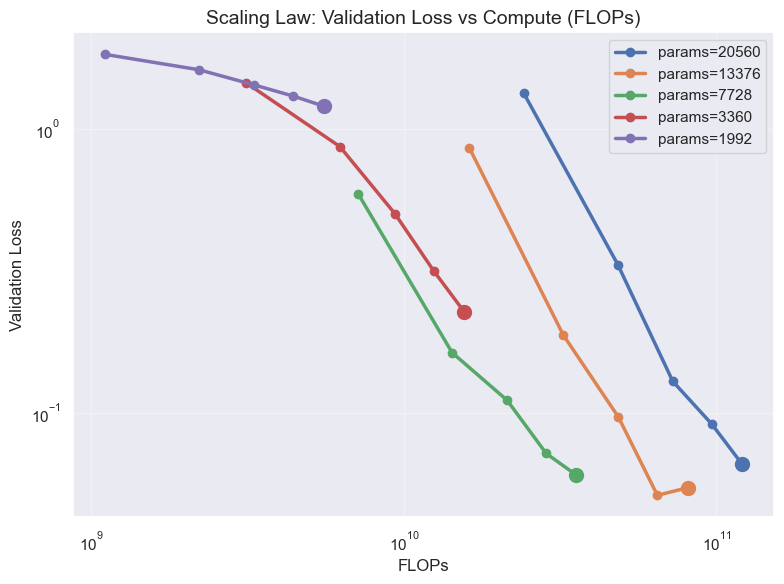

/Users/Akseldkw/Desktop/Columbia/COMS4776/homework/HW2/utils.py:186: RankWarning: Polyfit may be poorly conditioned
  poly_coeffs = np.polyfit(np.log10(flops), np.log10(val_loss), 5)
/Users/Akseldkw/Desktop/Columbia/COMS4776/homework/HW2/utils.py:186: RankWarning: Polyfit may be poorly conditioned
  poly_coeffs = np.polyfit(np.log10(flops), np.log10(val_loss), 5)
/Users/Akseldkw/Desktop/Columbia/COMS4776/homework/HW2/utils.py:186: RankWarning: Polyfit may be poorly conditioned
  poly_coeffs = np.polyfit(np.log10(flops), np.log10(val_loss), 5)
/Users/Akseldkw/Desktop/Columbia/COMS4776/homework/HW2/utils.py:186: RankWarning: Polyfit may be poorly conditioned
  poly_coeffs = np.polyfit(np.log10(flops), np.log10(val_loss), 5)
/Users/Akseldkw/Desktop/Columbia/COMS4776/homework/HW2/utils.py:186: RankWarning: Polyfit may be poorly conditioned
  poly_coeffs = np.polyfit(np.log10(flops), np.log10(val_loss), 5)


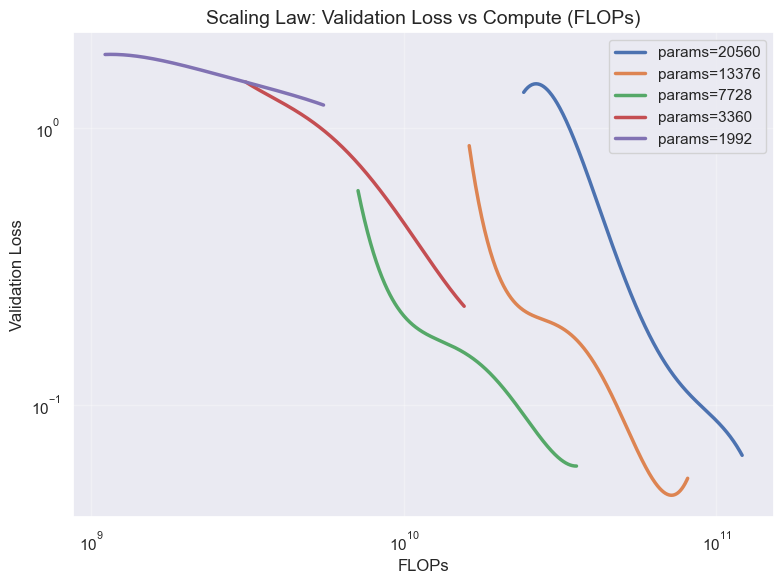

In [37]:
plot_scaling_law(all_results)

plot_scaling_law_poly(all_results)

## Step 2: Optimal Number of Parameters

Using the previously created training runs, we'll fit quadratic functions to the (parameter count, validation loss) pairs to estimate the optimal number of parameters for a given compute budget. We'll then fit a line to this set of optimal parameters to estimate the optimal number of parameters for a compute budget of 1e15.

In [68]:
def find_optim_params(params: torch.Tensor, loss: torch.Tensor):
    x = np.array(params.cpu())
    y = np.array(loss.cpu())

    p = np.polyfit(np.log10(x), y, 2)
    optimal_log_params = -(p[1]) / (2 * p[0])
    optimal_params = 10 ** (optimal_log_params)

    return optimal_params


target_flops = [8e9, 16e9, 32e9, 64e9, 128e9]
colors = ["#E41A1C", "#377EB8", "#4DAF4A", "#984EA3", "#FF7F00"]
params_vs_loss = []
optimal_params = []

for target in target_flops:
    parameters = []
    val_loss = []

    for params, results in all_results.items():
        loss = interpolate(results["val_loss"], results["flops"], target, deg=4)

        # interpolate returns None if target is out of range
        if loss != None:
            parameters.append(params)
            val_loss.append(loss)

    sorted_indices = torch.argsort(torch.tensor(parameters)).to(device)
    parameters = torch.tensor(parameters).to(device)[sorted_indices]
    val_loss = torch.tensor(val_loss).to(device)[sorted_indices]
    try:
        optimal_params.append(find_optim_params(parameters, val_loss))
        params_vs_loss.append((parameters.tolist(), val_loss.tolist()))
    except Exception as e:
        print(
            f"{optimal_params=}\n\n{params_vs_loss=}\n\n{parameters=}\n\n{val_loss=}\n\n{target=}"
        )

/var/folders/dj/k5kk5wk90vvcnb_wphpw490r0000gn/T/ipykernel_84499/2694499551.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(params.cpu())
/var/folders/dj/k5kk5wk90vvcnb_wphpw490r0000gn/T/ipykernel_84499/2694499551.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y = np.array(loss.cpu())


In [63]:
print(
    type(target_flops),
    type(target_flops[0]),
    type(optimal_params),  # type(optimal_params[0]),
    type(all_results),
    type(params_vs_loss),  # type(params_vs_loss[0]),
    type(colors),
    type(colors[0]),
)

<class 'list'> <class 'float'> <class 'list'> <class 'dict'> <class 'list'> <class 'list'> <class 'str'>


8.00 GFlops: Optimal params = 3,568
16.00 GFlops: Optimal params = 9,677
32.00 GFlops: Optimal params = 9,399
64.00 GFlops: Optimal params = 9,402
128.00 GFlops: Optimal params = 9,401


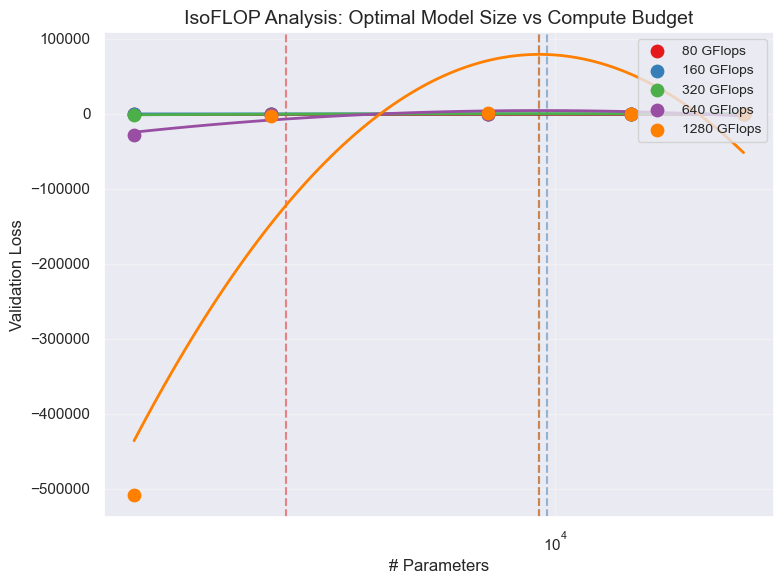

In [64]:
plot_isoflop(target_flops, colors, params_vs_loss, optimal_params)

y = 0.27543058930713765x + 0.998078859326133


/Users/Akseldkw/Desktop/Columbia/COMS4776/homework/HW2/utils.py:275: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  


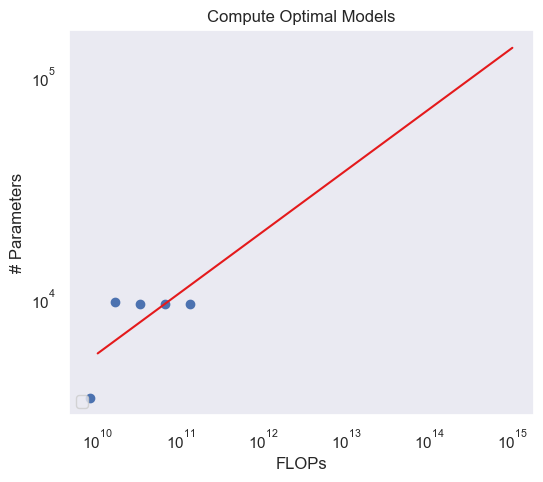

In [65]:
plot_flops_params(target_flops, optimal_params)

## Step 3: Optimal Number of Tokens

Finally, we'll perform a similar analysis to the previous step, only this time determining the optimal number of tokens for a budget of 1e15 flops.

y = 0.7150217644676573x + -1.5955079578538036


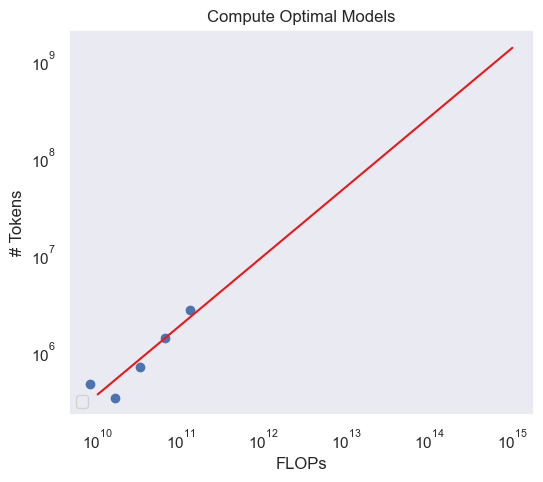

In [67]:
plot_flops_tokens(target_flops, optimal_params, all_results)